# Estudio comparativo de algoritmos en un problema de *k-armed bandit* sobre distribuciones normales

*Description*: El experimiento compara el rendimiento de tres familias de algoritmos (*greedy*, UCB y métodos de ascenso de gradiente) sobre un bandido de 10 brazos cuyas recompensas siguen distribuciones normales.

`Author: Juan Diego Gallego Nicolás`
`Email: jdiego.gallego@um.es`
`Date: 2026/02/16`

## Preparación del entorno

In [1]:
# TODO Copiar el repositorio

In [2]:
#@title Importamos todas las clases y funciones

import sys
sys.path.append('../src')

import numpy as np

from src.agents import *
from src.arms import ArmNormal, Bandit
from src.plotting import *

In [3]:
#@title Aseguramos reproducibilidad
SEED = 30
np.random.seed(SEED)

## Experimento

Un experimento quedará definido como una lista de algoritmos aplicados a un bandidode k-brazos durante un número de pasos de tiempo y ejecuciones determinado. Se comparan los resultados en términos de la recompensa promedio y del arrepentimiento.

In [4]:
#@title Función para ejecutar el experimento

def run_experiment(bandit: Bandit, agents: list[Agent], steps: int, runs: int):
    optimal_arm, _ = bandit.get_optimal_arm()
    rewards = np.zeros((len(agents), steps))
    optimal_selections = np.zeros((len(agents), steps))

    for run in range(runs):
        current_bandit = Bandit(bandit.arms)
        for agent in agents:
            agent.reset()

        total_rewards_per_agent = np.zeros(len(agents))

        for step in range(steps):
            for idx, agent in enumerate(agents):
                action = agent.get_action()
                reward = current_bandit.pull_arm(action)
                agent.update(action, reward)

                rewards[idx, step] += reward
                total_rewards_per_agent[idx] += reward

                if action == optimal_arm:
                    optimal_selections[idx, step] += 1
            
    rewards /= runs
    optimal_selections /= runs
    return rewards, optimal_selections

In [5]:
#@title Parámetros comunes a todos los experimentos
steps = 1000 # Número de pasos para la ejecución de cada agente
runs = 500 # Número de ejecuciones para promediar los resultados

## Bandidos

Para evaluar los diferentes algoritmos vamos a utilizar dos tipos de bandidos:
* Fácil: la varianza será una décima parte del rango de medias de las distribuciones.
* Difícil: la varianza será la mitad del rango de medias de las distribuciones.
Para el segundo bandido deberemos observar una convergencia más lenta.

In [6]:
np.random.seed(SEED)

K = 10
mu_min = 0.0
mu_max = 10.0
sigma_1 = (mu_max - mu_min) / 10
sigma_2 = (mu_max - mu_min) / 2

easy_bandit = Bandit(arms=ArmNormal.generate_arms(k=K, mu_min=mu_min, mu_max=mu_max, sigma=sigma_1))
hard_bandit = Bandit(arms=ArmNormal.generate_arms(k=K, mu_min=mu_min, mu_max=mu_max, sigma=sigma_2))

def show_bandit_info(bandit: Bandit, title: str):
    print(f"--- {title} ---")
    print(bandit)
    optimal_arm, optimal_value = bandit.optimal_arm
    print(f"Brazo óptimo: {optimal_arm} con media {optimal_value}")

show_bandit_info(easy_bandit, "Bandido Fácil")
print("\n")
show_bandit_info(hard_bandit, "Bandido Difícil")

--- Bandido Fácil ---
Bandit with 10 arms: ArmNormal(mu=1.64, sigma=1.0), ArmNormal(mu=2.35, sigma=1.0), ArmNormal(mu=3.81, sigma=1.0), ArmNormal(mu=3.47, sigma=1.0), ArmNormal(mu=5.86, sigma=1.0), ArmNormal(mu=6.44, sigma=1.0), ArmNormal(mu=6.63, sigma=1.0), ArmNormal(mu=4.07, sigma=1.0), ArmNormal(mu=9.63, sigma=1.0), ArmNormal(mu=9.92, sigma=1.0)
Brazo óptimo: 9 con media 9.92


--- Bandido Difícil ---
Bandit with 10 arms: ArmNormal(mu=0.9, sigma=5.0), ArmNormal(mu=1.36, sigma=5.0), ArmNormal(mu=1.96, sigma=5.0), ArmNormal(mu=2.35, sigma=5.0), ArmNormal(mu=2.39, sigma=5.0), ArmNormal(mu=5.18, sigma=5.0), ArmNormal(mu=5.44, sigma=5.0), ArmNormal(mu=7.67, sigma=5.0), ArmNormal(mu=9.34, sigma=5.0), ArmNormal(mu=9.94, sigma=5.0)
Brazo óptimo: 9 con media 9.94


## Familia $\epsilon$-greedy

La primera familia de técnicas que vamos a probar es el conjunto $\epsilon$-greedy. Distinguimos entre los métodos puros ($\epsilon$ constante) y con decaimiento ($\epsilon$ decrece con el número de ejecuciones). El tipo de decaimiento es invesamente proporcional al número de ejecuciones, siguiendo la expresión: 

$$\epsilon_{t}=\frac{\epsilon_0}{1+\lambda t}$$

Empezamos por el bandido con brazos de baja varianza.

In [7]:
#@title Definimos los agentes a comparar

algorithms = [
    EpsilonGreedyAgent(k_arms=K, epsilon=0.1),
    EpsilonGreedyAgent(k_arms=K, epsilon=0.01),
    EpsilonGreedyAgent(k_arms=K, epsilon=0.005),
    EpsilonDecayAgent(k_arms=K, e_start=1.0, e_end=0.01, lda=0.01),
    EpsilonDecayAgent(k_arms=K, e_start=1.0, e_end=0.01, lda=0.05),
    EpsilonDecayAgent(k_arms=K, e_start=1.0, e_end=0.01, lda=0.1)
]

### Bandido sencillo

In [8]:
#@title Experimento ara el bandido fácil

rewards, optimal_selections = run_experiment(easy_bandit, algorithms, steps, runs)
_, optimal_value = easy_bandit.optimal_arm

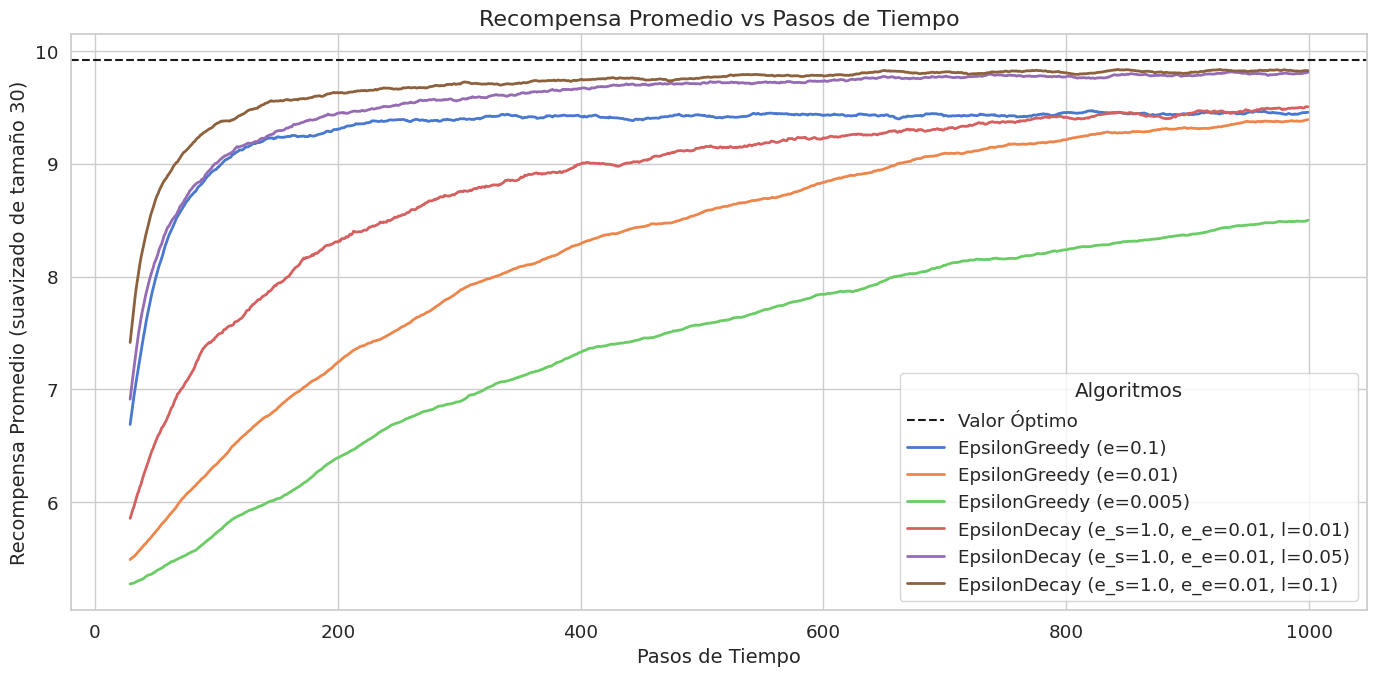

In [9]:
#@title Resultados para el bandido fácil

plot_average_rewards(steps, rewards, algorithms, optimal_value=optimal_value, window_size=30)

La imagen muestra un gráfico de líneas titulado **"Recompensa Promedio vs Pasos de Tiempo"**, donde se analiza el desempeño promedio de seis estrategias de algoritmos de la familia $\epsilon$-greedy. En el **eje x** se representan los **pasos de tiempo**, mientras que en el **eje y** se muestra una versión suavizada de la **recompensa promedio**. Este suavizado se ha hecho con un filtro de ventana uniforme de tamaño 30 con el fin de eliminar las rápidas oscilaciones de la gráfica sin perder de vista la tendencia de crecimiento.

Analicemos los seis métodos por separado:
1. Las tres variantes $\epsilon$-greedy puras:
    * **Verde ($\epsilon=0.005$)**: representa una estrategia casi totalmente explotadora (en 1000 iteraciones se espera que la exploración se realice solo 5 veces). Muestra un crecimiento muy lento y tras 1000 iteraciones no se acerca al óptimo.
    * **Naranja ($\epsilon=0.01$)**: representa una estrategia con una probabilidad pequeña (1%) de elegir una acción aleatoria (exploración). Su crecimiento es moderadamente más rápido que el de la versión anterior.
    * **Azul ($\epsilon=0.1$)**: representa una estrategia con una probabilidad alta (10%) de explorar acciones aleatorias. Su crecimiento inicial es muy rápido y es el que obtiene un mejor resultado a la larga.
2. Las tres variantes $\epsilon$-greedy con decaimiento:
    * **Roja ($\epsilon_{ini}=1.0, \epsilon_{min}=0.01, \lambda=0.01$)**: como el resto de los métodos con decaimiento, la exploración inicial se sitúa en el 100%. Con un $\lambda=0.01$, tras 1000 iteraciones la probabilidad de exploración es de ~9.09%. El crecimiento es similar al de la línea naranja y su valor final es similar al de la azul.
    * **Morada ($\epsilon_{ini}=1.0, \epsilon_{min}=0.01, \lambda=0.05$)**: representa una estrategia con decaimiento cinco veces más rápido que el de la línea roja, llegando a un 10% de exploración en la iteración 180 y a un 1.96% en la 1000. Es el segundo método en cuanto a velocidad de aproximación al óptimo y en lo relativo al promedio final.
    * **Marrón ($\epsilon_{ini}=1.0, \epsilon_{min}=0.01, \lambda=0.1$)**: representa una estrategia con decaimiento dos veces más rápido que el anterior, llegando a un 10% de exploración en la iteración 90 y a un 1% en la 990 (en iteraciones posteriores el decaimiento se paraliza, saturando el valor de $\epsilon$ en 0.01). Es el método ganador, llegando a valores cercanos al óptimo (>9) alrededor de la iteración 200. Su valor promedio final es muy similar, aunque superior, al de la línea morada.

En definitiva, el mecanismo de decaimiento mejora enormemente a los algoritmos $\epsilon$-greedy básicos, siendo mejor para este problema un decaimiento fuerte (0.1).

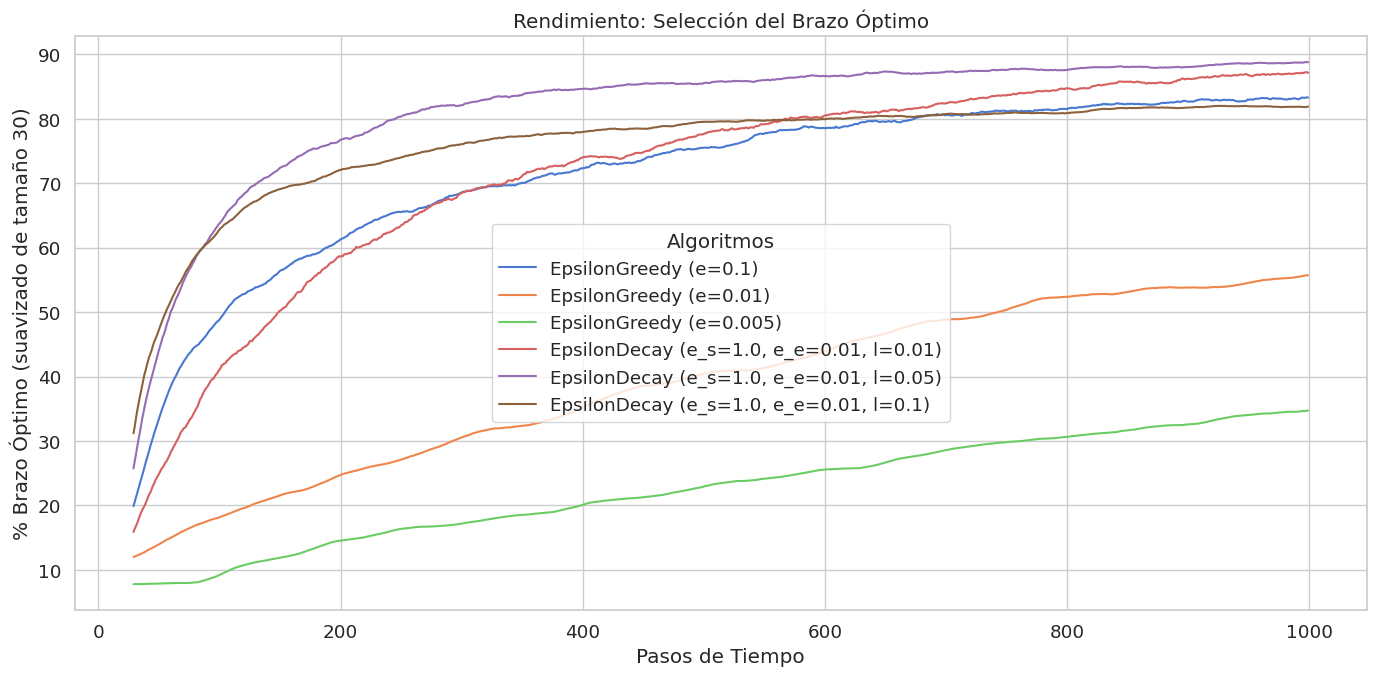

In [10]:
#@title Mostrar el porcentaje de selección del brazo óptimo para el bandido fácil
plot_optimal_selections(steps, optimal_selections, algorithms, window_size=30)


En esta otra imagen titulada **"Rendimiento: Selección del Brazo Óptimo"**, podemos ver la proporción de las veces (**eje y**) que **se selecciona el brazo óptimo** entre todas las ejecuciones en cada **paso de tiempo** (**eje x**).

Podemos destacar los siguientes fenómenos:
1. Las estrategias $\epsilon$-greedy básicas con $\epsilon<<0.1$ no son capaces de encontrar el brazo óptimo consistentemente en la iteración 1000.
2. La línea **marrón** (decaimiento rápido) gana en las iteraciones tempranas (<200), pero a partir de la iteración 800 es la cuarta de las seis en lo que a la selección del brazo óptimo se refiere.
3. El agente **rojo** (decaimiento lento) destaca por sobre las demás, eligiendo el brazo óptimo casi el 90% de las veces que se hace la elección del brazo número 1000 a pesar de una peor tasa de éxito en las primeras iteraciones.

Estos dos últimos puntos no son para nada contradictorios con los resultados de la gráfica previa. Nos indican que el agente con decaimiento lento "pierde el tiempo" con brazos sub-óptimos, mientras que su hermano con decaimiento rápido se adhiere a brazos, no necesariamente óptimos, pero sí con valores muy cercanos a él.

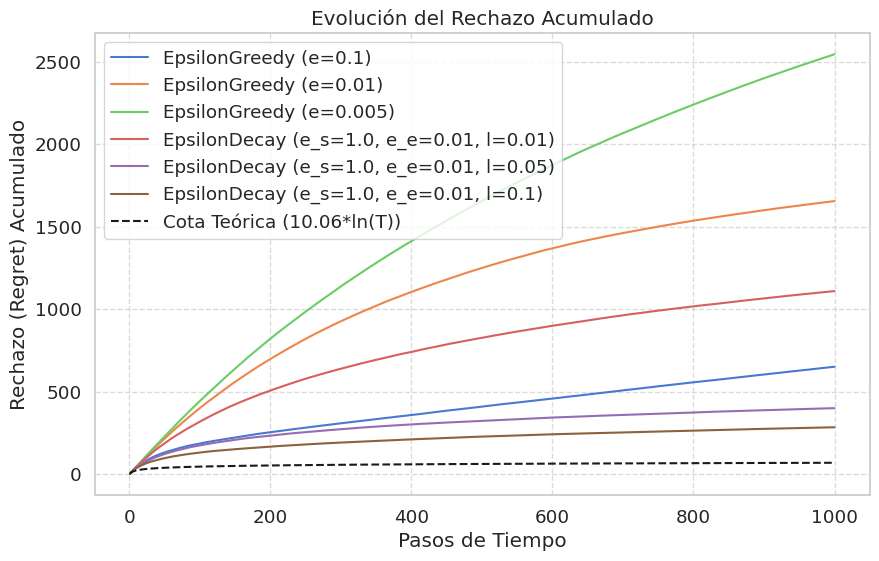

In [11]:
_, optimal_value = easy_bandit.optimal_arm
regret_per_step = optimal_value - rewards
cumulative_regret = np.cumsum(regret_per_step, axis=1)

c = easy_bandit.get_theoretical_constant()
plot_regret(steps, cumulative_regret, algorithms, cte=c)

Si nos fijamos ahora en el gráfico **"Evolución del Rechazo Acumulado"** (**eje x**) frente al número de pasos (**eje y**), apreciamos el "coste" del decaimiento lento que no se veía tan claro en la gráfica del procentaje de aciertos. El agente **rojo** (decaimiento lento) acumula inicialmente mucho arrepentimiento debido a su exploración inicial. En contraposición a él, el **morado** y el **marrón** (decaimiento moderado y rápido) mantienen un arrepentimiento que se aproxima a la tendencia del mínimo teórico. Achacamos este fenómeno al decrecimiento rápido de la exploración.

### Bandido complejo

In [12]:
#@title Entrenamos con el bandido difícil

rewards, optimal_selections = run_experiment(hard_bandit, algorithms, steps, runs)
_, optimal_value = hard_bandit.optimal_arm

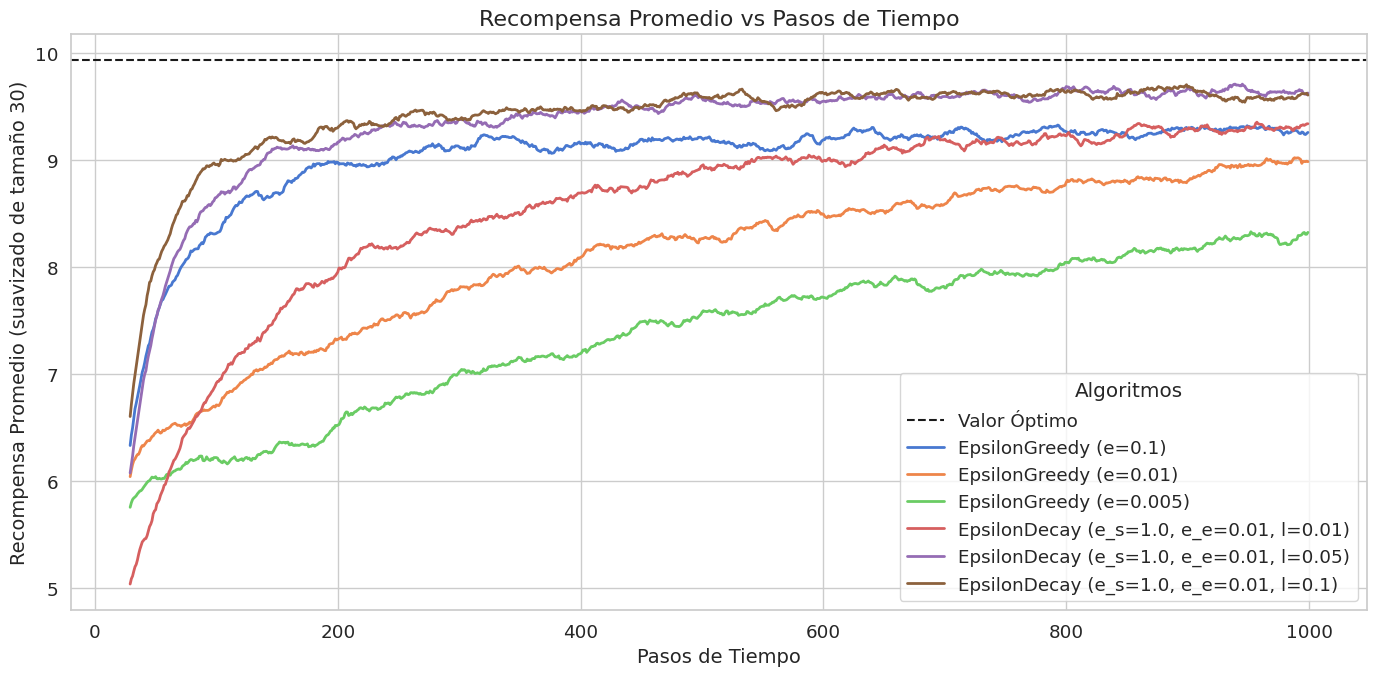

In [13]:
# Resultados para el bandido difícil

plot_average_rewards(steps, rewards, algorithms, optimal_value=optimal_value, window_size=30)

Esta gráfica homóloga de la primera que mostrábamos con el bandido de varianza pequeña evidencia el impacto del ruido en el proceso de aprendizaje:

1. Los valores finales se alejan más del óptimo. Con tanta varianza, las distribuciones de recompensa se solapan demasiado como para que un aprendizaje de 1000 iteraciones pueda distinguir bien los brazos buenos de los malos.
2. Los algoritmos $\epsilon$-greedy acaban los tres a la cola y ordenados por $\epsilon$ creciente.
3. Sin embargo, la estrategia estática con exploración alta compite con las versiones con decaimiento.
4. Incluso con el suavizado (window=30) las líneas son mucho más "temblorosas" que en la gráfica anterior. Esto será en su mayoría causado por la inestabilidad en las recompensas instantáneas.

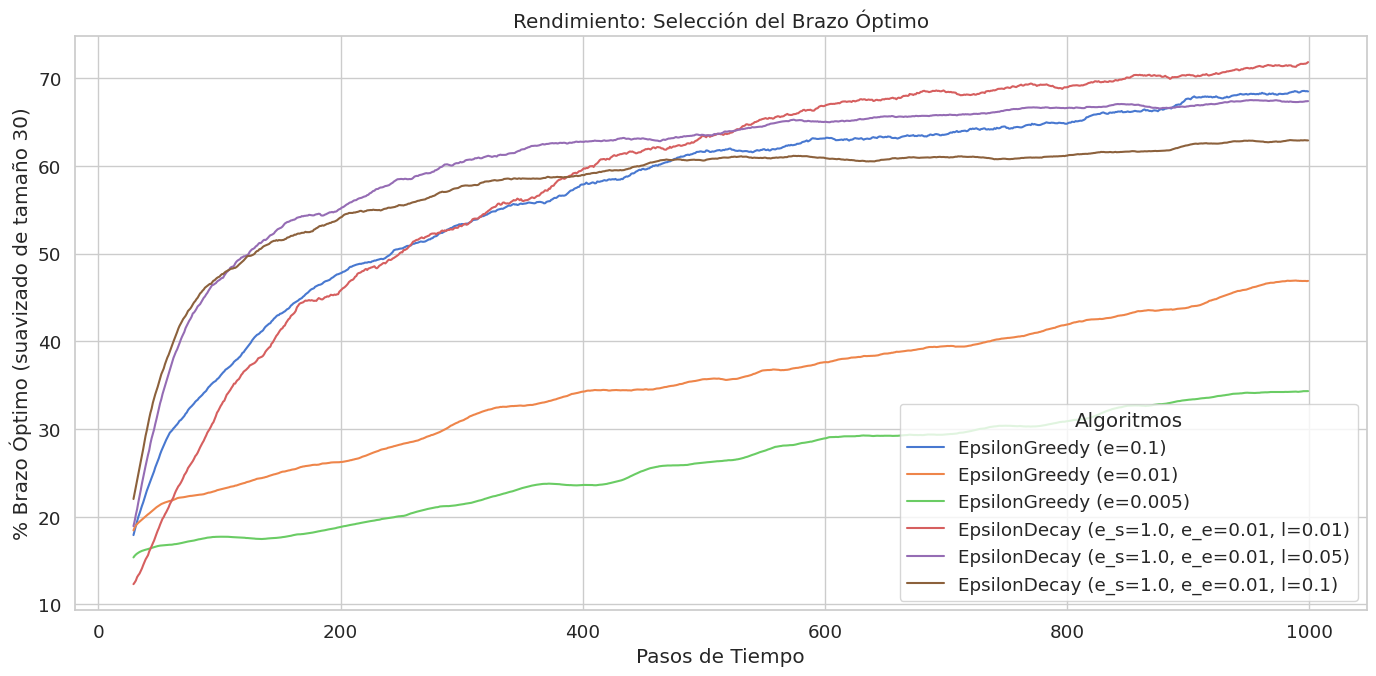

In [14]:
#@title Mostrar el porcentaje de selección del brazo óptimo para el bandido difícil
plot_optimal_selections(steps, optimal_selections, algorithms, window_size=30)


Con respecto a la elección del brazo óptimo, el agente **morado** (decaimiento moderado) ha dominado a los demás, eligiendo el mejor brazo alrededor del 70% de las veces en la iteración 1000. Nótese que la media del brazo óptimo y la del segundo difieren en solo 0.60 puntos, siendo con una varianza alta difíciles de distinguir.

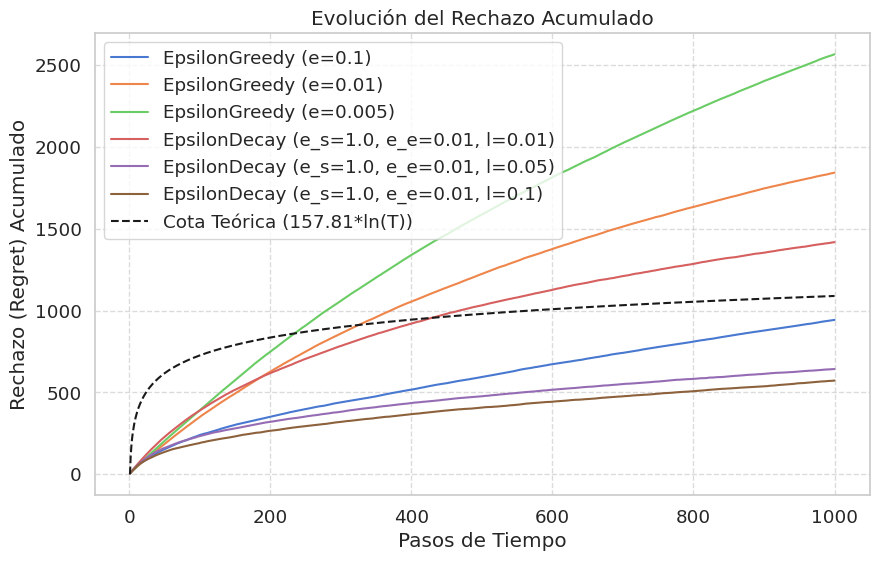

In [15]:
_, optimal_value = hard_bandit.optimal_arm
regret_per_step = optimal_value - rewards
cumulative_regret = np.cumsum(regret_per_step, axis=1)

c = hard_bandit.get_theoretical_constant()
plot_regret(steps, cumulative_regret, algorithms, cte=c)

Finalmente, al pasar de $\sigma=1$ a $\sigma=5$, el coste del aprendizaje se ha disparado. El menor arrepentimiento medio ronda los 500 puntos frente a los ~250 que se alcanzaban con el bandido más simple.

Además:
1. Las estrategias de decaimiento moderado y alto tienen comportamientos similares, obteniendo el menor arrepentimiento la estrategia moderada.
2. La estrategia estática con un 10% de exploración mantiene un arrepentimiento intermedio entre el peor de los métodos con decaimiento y el mejor.
3. Las otras estrategias estáticas siguen tendencias malas.

## Familia UCB

La familia de algoritmos **UCB** (Upper confidence bound) se fundamenta en el principio de "optimismo ante la incertidumbre". A diferencia de los métodos $\epsilon$ greedy que exploran al azar, UCB construye un intervalo de confianza sobre la media estimada de cada brazo y selecciona aquel con el límite superior más alto. Sigue la fórmula:
$$A_t=argmax\left\{Q_t(a)+c\sqrt{\frac{\ln{t}}{N_t(a)}}\right\},$$
equilibrando la **explotación** basada en la recompensa media $Q_t$ y la exploración (el término de la raíz). La exploración crece para los dados poco visitados y disminuye conforme se obtiene mayor información. El parámetro c regula la amplitud del intervalo: determina cuanta desviación estándar por encima de la media considera un punto plausible.

In [16]:
#@title Definimos los agentes a comparar

algorithms = [
    UCBAgent(k_arms=K, c=0.5),
    UCBAgent(k_arms=K, c=1.0),
    UCBAgent(k_arms=K, c=np.sqrt(2)),
    UCBAgent(k_arms=K, c=2.0),
    UCBAgent(k_arms=K, c=5.0)
]

### Bandido sencillo

In [17]:
#@title Experimento para el bandido fácil

rewards, optimal_selections = run_experiment(easy_bandit, algorithms, steps, runs)
_, optimal_value = easy_bandit.optimal_arm

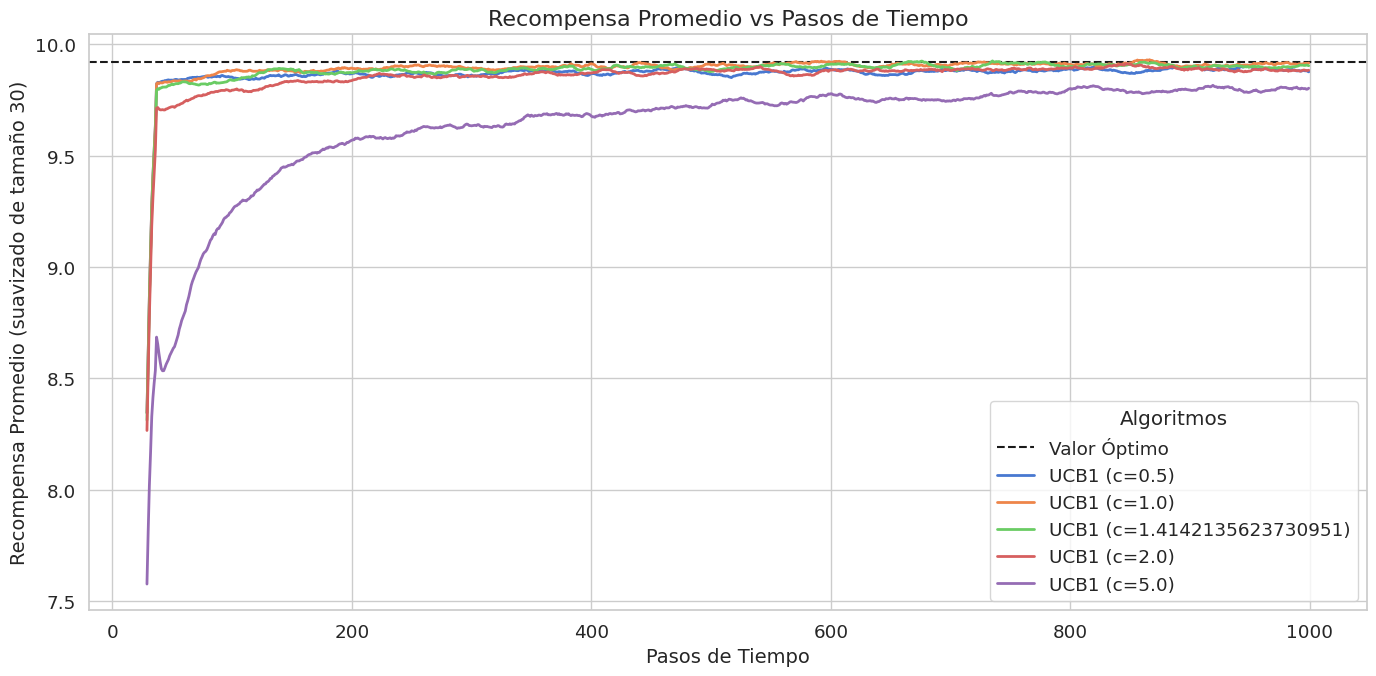

In [18]:
#@title Resultados para el bandido fácil

plot_average_rewards(steps, rewards, algorithms, optimal_value=optimal_value, window_size=30)

A diferencia de los algortimos $\epsilon$-greedy que tenían una convergencia curvada monónona, estos agentes presentan saltos muy tempranos y alcanzan pronto valores cercanos al óptimo. 

Cuatro de los cinco agentes convergen de forma muy similar. La "oveja negra" es la línea **morada** (c=5). En los 100 primeros pasos su ascenso es muy lento. Esto se debe a que hemos tomado un valor de $c$ excesivamente grande: el agente necesita muchas muestras antes de determinar que un cierto brazo no merece la pena. El resto estan ordenados de por $c$ de forma inversa en cuanto a velocidad de convergencia. De todas formas, si nos fijamos en la escala podemos ver de forma clara la diferencia abismal entre estos métodos y los $\epsilon$-greedy.

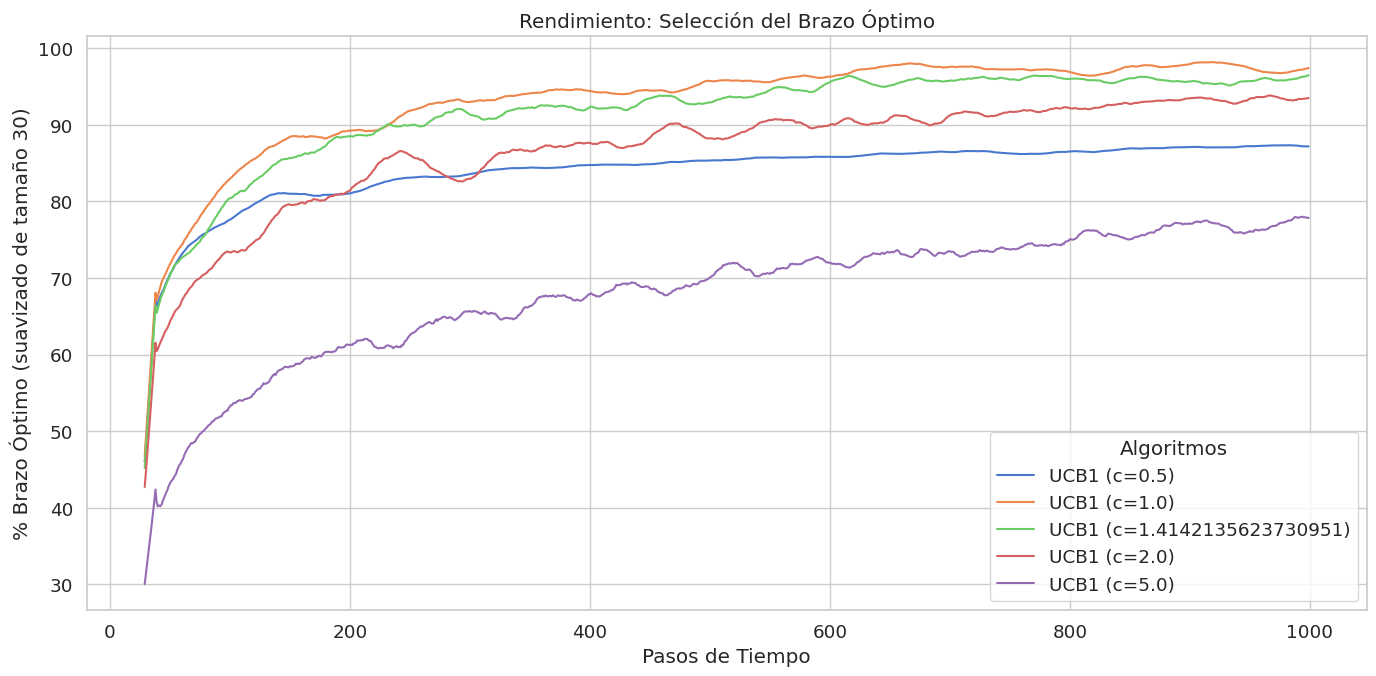

In [19]:
#@title Mostrar el porcentaje de selección del brazo óptimo para el bandido fácil
plot_optimal_selections(steps, optimal_selections, algorithms, window_size=30)


En cuanto a la gráfica de selección del brazo óptimo, extraemos las siguientes conclusiones:
1. Las líneas **naranja** (c=1) y **verde** (c=$\sqrt{2}$) identifican el mejor brazo.
2. La línea **azul** (c=0.5) crece muy rápido al principio pero acaba aplanándose. Al usar un $c$ tan bajo el agente subestima la incertidumbre: si tiene mala suerte con el brazo óptimo al principio, su límite superior de confianza (UCB) cae rápido.
3. La línea **morada** (c=5) tiene mal comienzo y mal final. Sufre de sobre-exploración hasta en iteraciones altas.
4. Tres de los cinco algoritmmos superan el 90% en la iteración 1000 frente a cero de los seis $\epsilon$-greedy.

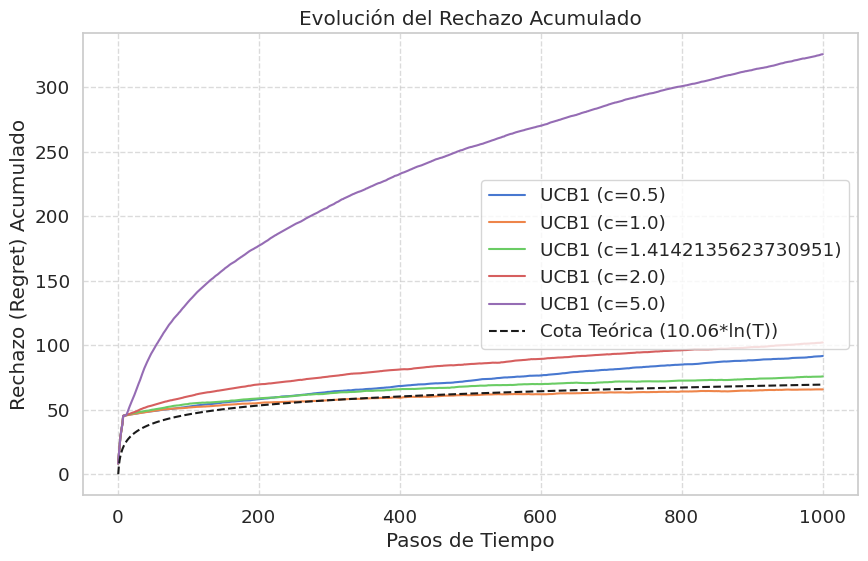

In [20]:
_, optimal_value = easy_bandit.optimal_arm
regret_per_step = optimal_value - rewards
cumulative_regret = np.cumsum(regret_per_step, axis=1)

c = easy_bandit.get_theoretical_constant()
plot_regret(steps, cumulative_regret, algorithms, cte=c)

Si nos fijamos en la evolución del rechazo comprobamos una abismal diferencia con los métodos $\epsilon$-greedy.

1. El peor de los modelos tiene un rechazo acumulado similar al mejor de los $\epsilon$-greedy.
2. Los demás, siguen la tendencia de la cota teórica, errando por constantes ínfimas.
3. La línea **naranja** (c=1) en este caso se sitúa por debajo de la línea de tendencia límite. Esto podría parecer una contradicción, pero la fórmula de Lai-Robbins es para un comportamiento asintótico, no puntual.

Para una baja varianza es bueno mantener una exploración baja.


### Bandido complejo

In [21]:
#@title Experimento para el bandido difícil

rewards, optimal_selections = run_experiment(hard_bandit, algorithms, steps, runs)
_, optimal_value = hard_bandit.optimal_arm

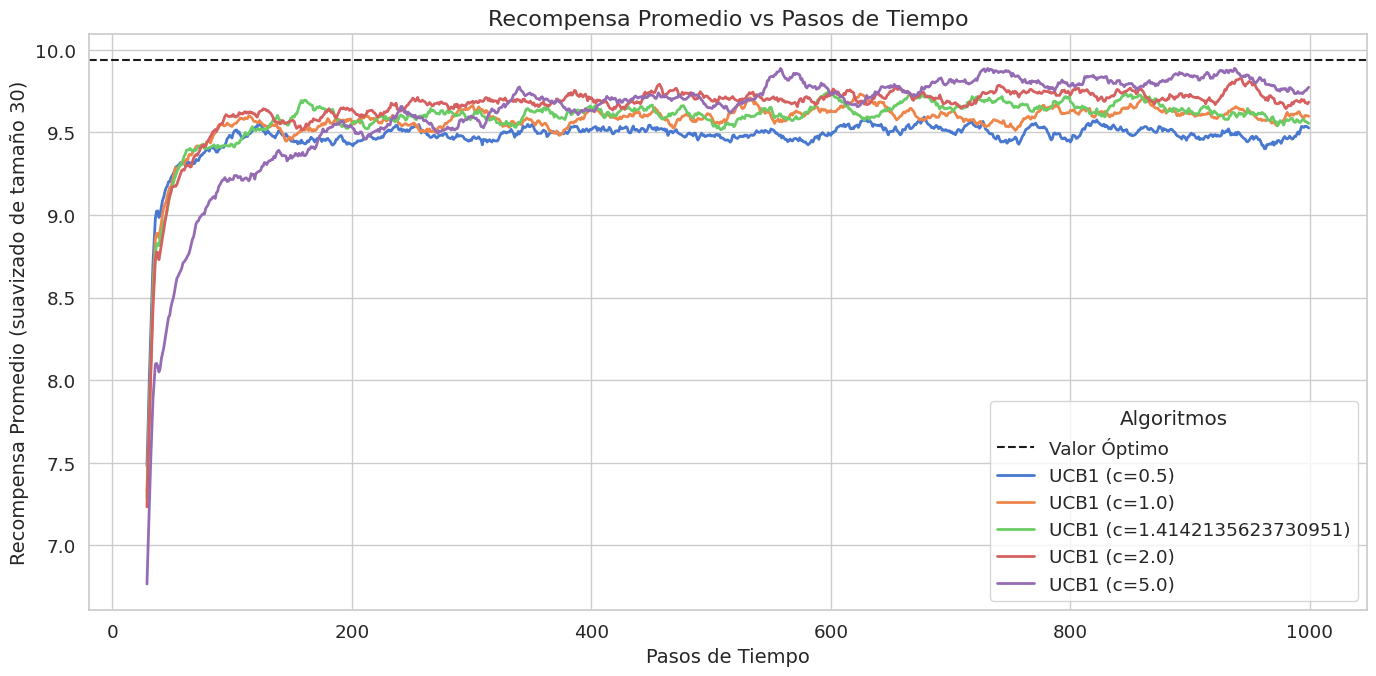

In [22]:
#@title Resultados para el bandido difícil

plot_average_rewards(steps, rewards, algorithms, optimal_value=optimal_value, window_size=30)

Vemos como la recompensa promedio el agente con $c$ grande crece lento al principio (al igual que con el agente de baja varianza), petro a partir de la iteración 800 se coloca como el campeón absoluto en cuanto a esta métrica. El parámetro está actuando implícitamente como un factor de escala para normalizar la desviación estándar. Mientras, los agentes con un nivel bajo de exploración (líneas **naranja**y **azul**), se estancan por debajo (quizá por quedarse en muchas simulaciones con el segundo mejor brazo).

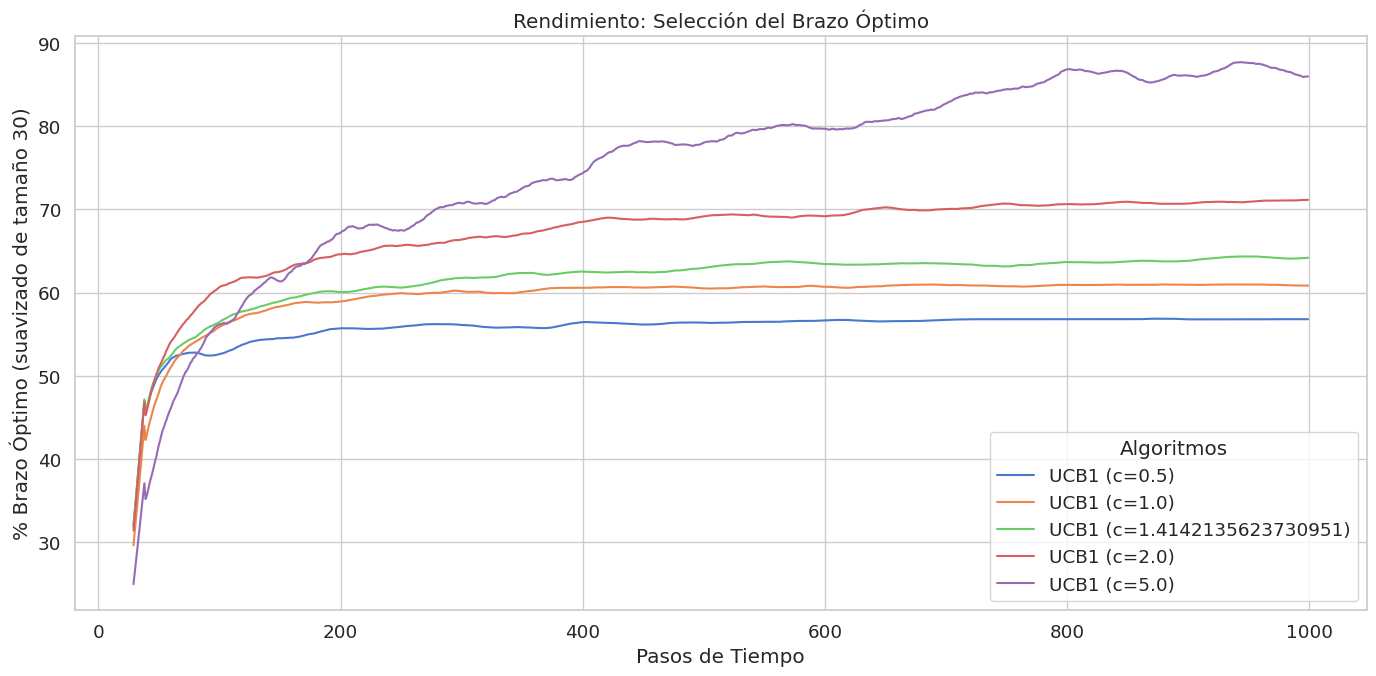

In [23]:
#@title Mostrar el porcentaje de selección del brazo óptimo para el bandido difícil
plot_optimal_selections(steps, optimal_selections, algorithms, window_size=30)

En cuanto a la selección del brazo óptimo, el algoritmo más explorador acaba encontrándolo el 85% de las veces  que llega a la iteración 1000. Gana en 15 puntos porcentuales al segundo y en casi 30 a los más conservadores.

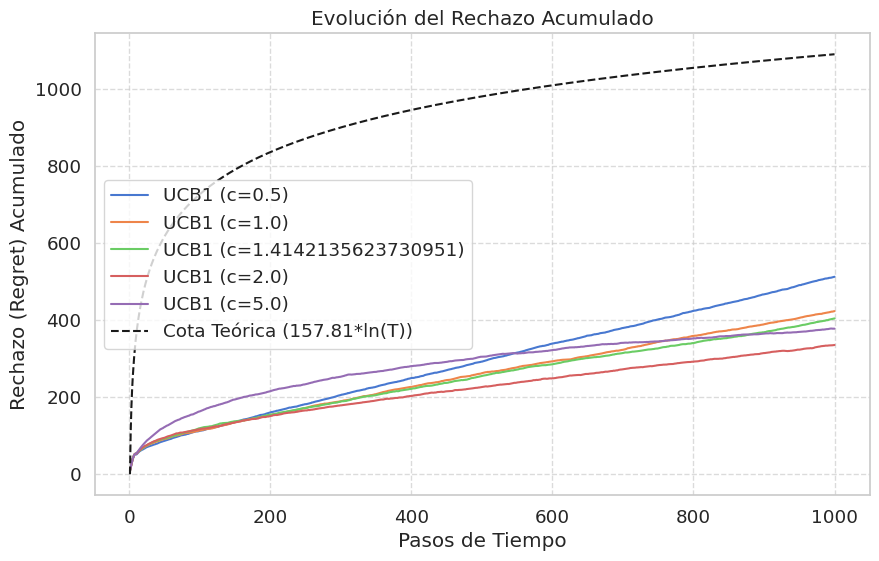

In [24]:
_, optimal_value = hard_bandit.optimal_arm
regret_per_step = optimal_value - rewards
cumulative_regret = np.cumsum(regret_per_step, axis=1)

c = hard_bandit.get_theoretical_constant()
plot_regret(steps, cumulative_regret, algorithms, cte=c)

Finalmente, el gráfico de la evolución del rechazo deja muchas cosas claras:
1. Las técnicas conservadores acumulan poco rechazo en etapas tempranas, pero su tendencia es parecida a una función lineal tras cierto número de iteraciones.
2. Una exploración moderada (línea **roja** con $c=2$) se comporta inicialmente como un agente conservador, pero a la larga acumula mucho menos arrepentimiento. Es el agente ganador en esta métrica.
3. El agente explorador ($c=5$) acumula mucho arrepentimiento en tramos iniciales en comparación a los demás, per a partir de la iteración 200 se produce un punto de inflexión que le hace adelantar a los demás de forma clara. Es, de hecho, el único gráfico de arrepentimiento que no parece convertirse en una recta tras las 1000 iteraciones.

## Descenso de gradiente

Como última familia de algoritmos vamos a probar los de descenso de gradiente. Aquí solo incluimos Softmax (o Exploración de Boltzman) controlando el parámetro de temperatura $\tau$. Este parámetro controla cómo influye la diferencia de los valores estimados $Q$ de los brazos en las probabilidades:
* Si $\tau \rightarrow \infty$ las probabilidad es se igualan, actuando el agente como un selector uniforme puramente explorador.
* Si $$\tau \rightarrow \nfty$ la acción con el valor más alto se lleva casi el 100% de probabilidad de ser escogida.
A diferencia de $\epsilon$-greedy, softmax es sensible a la magnitud de las recompensas. Si la fórmula aplicar es:
$$P(b_i)=\frac{e^{q_i/\tau}}{\sum e^{q_j/\tau}},$$
elegir $\tau=0.1$ con un brazo de recompensa media 9 probocaría un cálculo de $e^{90} >> 2^{63}$, provocando errores numéricos. Por tanto, vamos a probar valores de $\tau$ en el rango $[0.5,5]$.



In [25]:
algorithms = [
    SoftmaxAgent(k_arms=K, temperature=0.5),
    SoftmaxAgent(k_arms=K, temperature=1.0),
    SoftmaxAgent(k_arms=K, temperature=2.0),
    SoftmaxAgent(k_arms=K, temperature=3.0),
    SoftmaxAgent(k_arms=K, temperature=5.0)
]

### Bandido sencillo

In [26]:
#@title Experimento para el bandido fácil

rewards, optimal_selections = run_experiment(easy_bandit, algorithms, steps, runs)
_, optimal_value = easy_bandit.optimal_arm

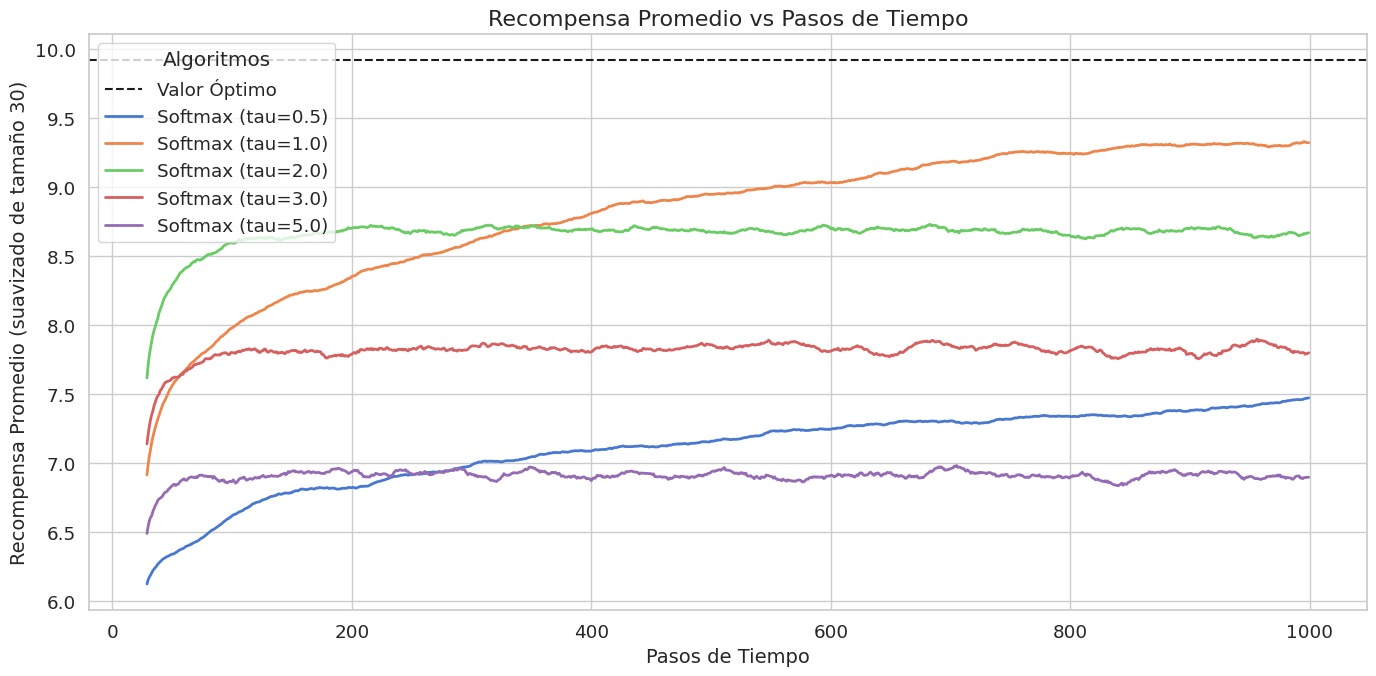

In [27]:
#@title Resultados para el bandido fácil

plot_average_rewards(steps, rewards, algorithms, optimal_value=optimal_value, window_size=30)

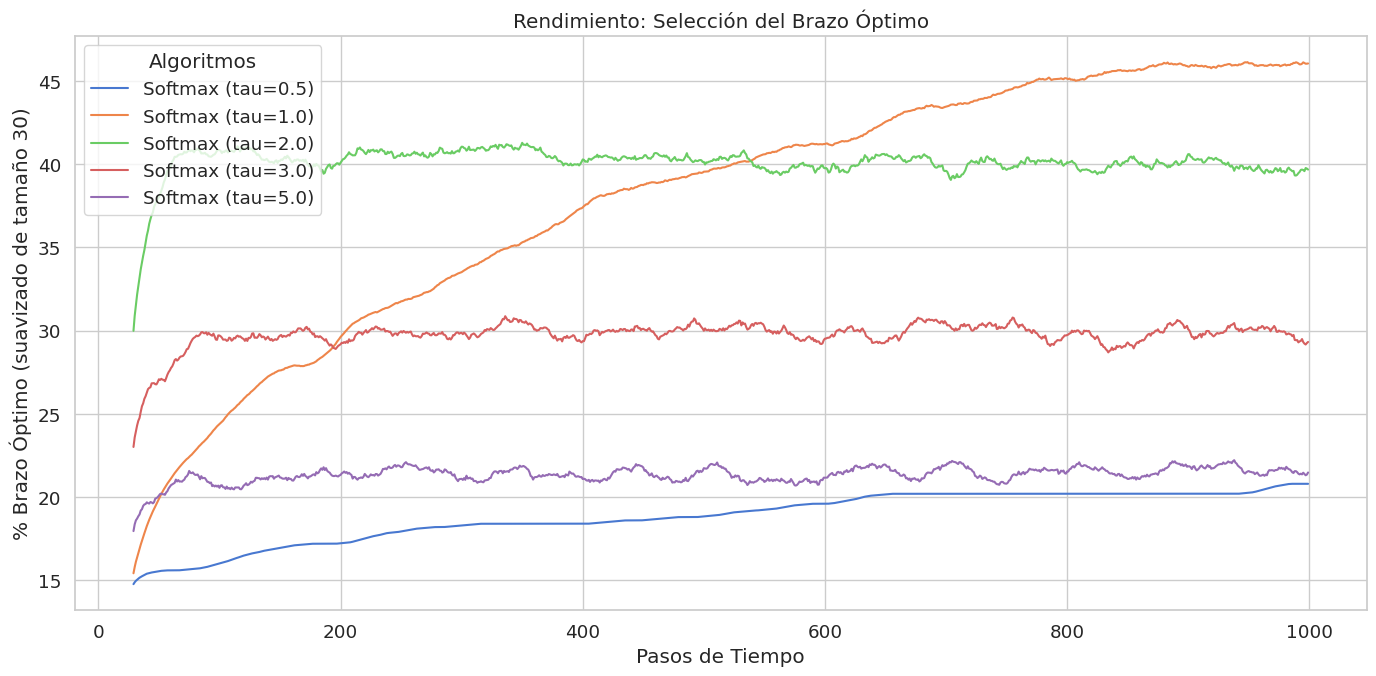

In [28]:
#@title Mostrar el porcentaje de selección del brazo óptimo para el bandido difícil
plot_optimal_selections(steps, optimal_selections, algorithms, window_size=30)

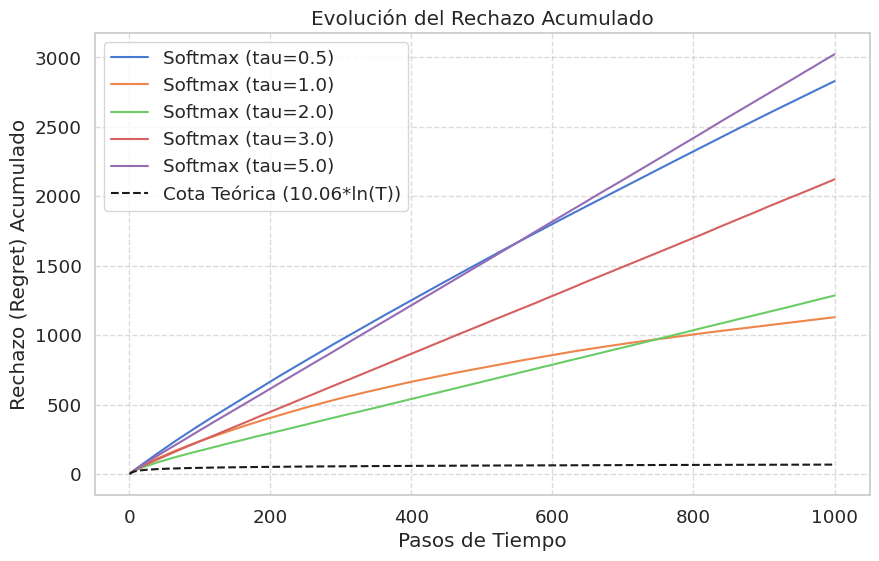

In [29]:
_, optimal_value = easy_bandit.optimal_arm
regret_per_step = optimal_value - rewards
cumulative_regret = np.cumsum(regret_per_step, axis=1)

c = easy_bandit.get_theoretical_constant()
plot_regret(steps, cumulative_regret, algorithms, cte=c)

### Bandido complejo

In [30]:
#@title Experimento para el bandido difícil

rewards, optimal_selections = run_experiment(hard_bandit, algorithms, steps, runs)
_, optimal_value = hard_bandit.optimal_arm

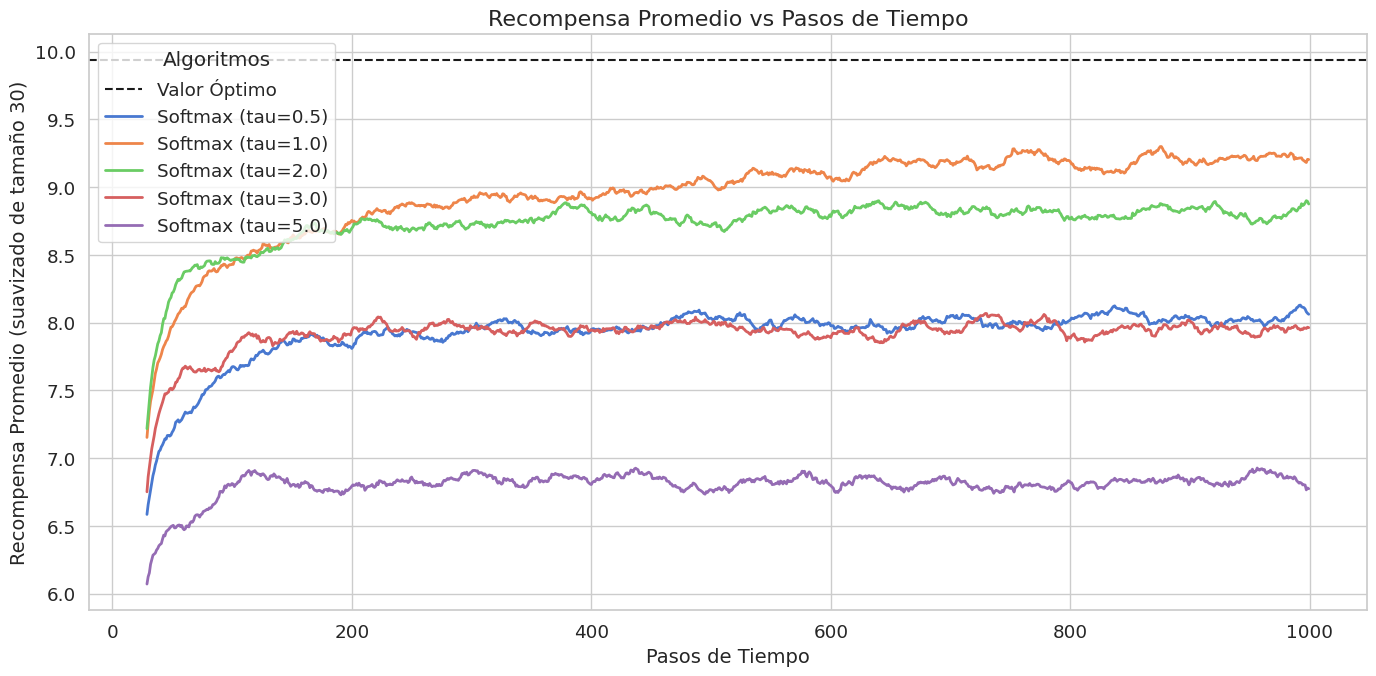

In [31]:
#@title Resultados para el bandido difícul

plot_average_rewards(steps, rewards, algorithms, optimal_value=optimal_value, window_size=30)

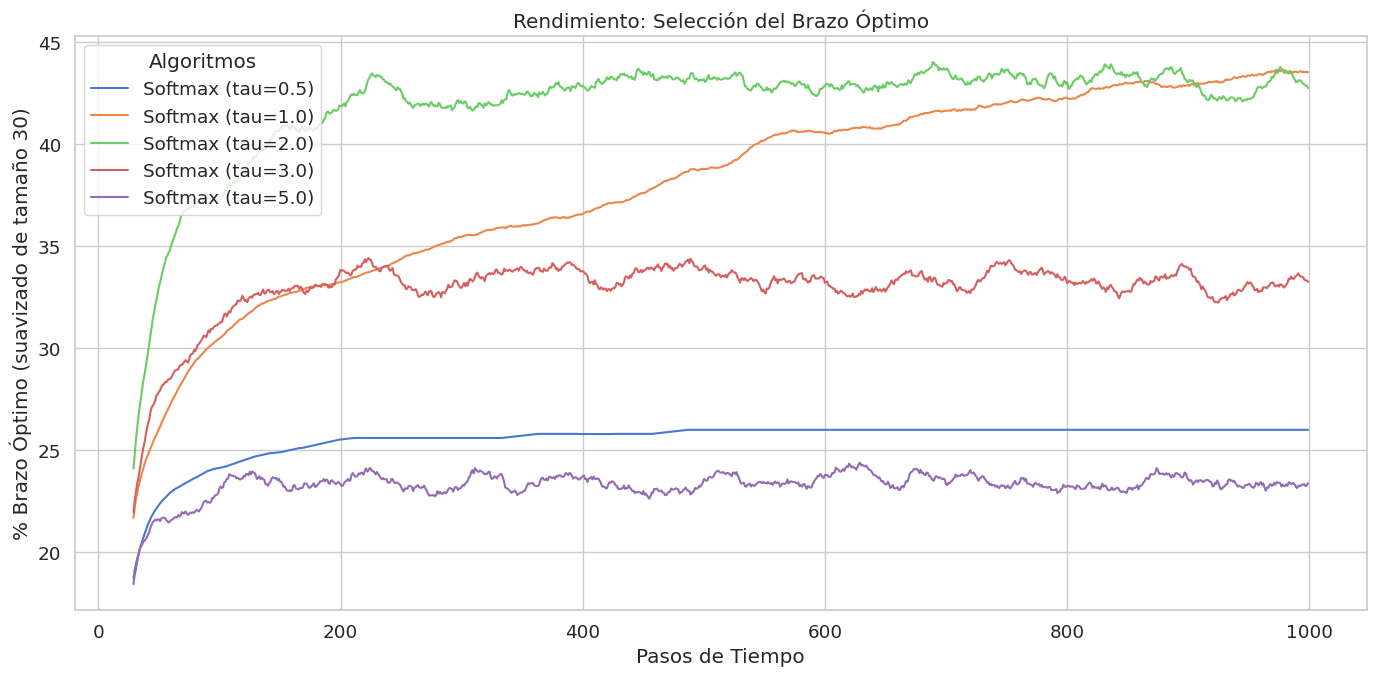

In [32]:
#@title Mostrar el porcentaje de selección del brazo óptimo para el bandido difícil
plot_optimal_selections(steps, optimal_selections, algorithms, window_size=30)

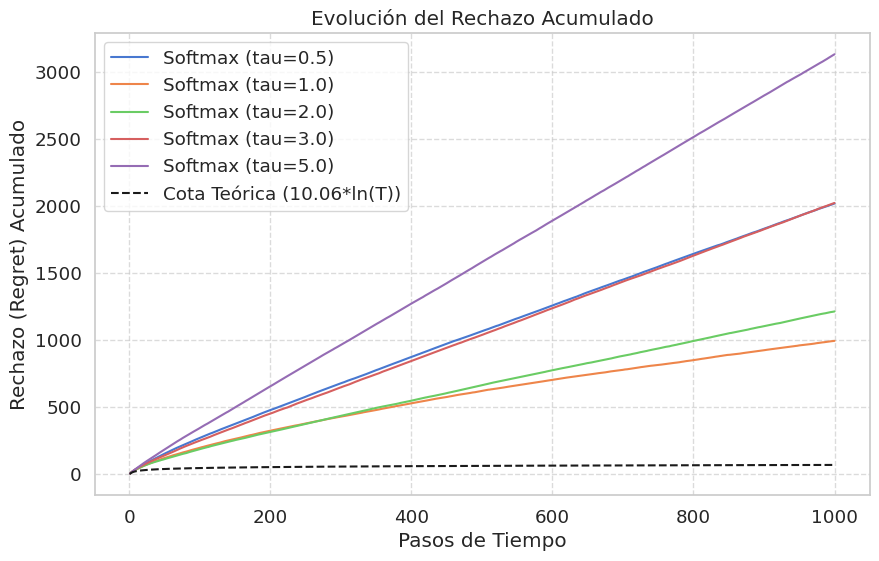

In [33]:
_, optimal_value = easy_bandit.optimal_arm
regret_per_step = optimal_value - rewards
cumulative_regret = np.cumsum(regret_per_step, axis=1)

c = easy_bandit.get_theoretical_constant()
plot_regret(steps, cumulative_regret, algorithms, cte=c)